# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sorgerator/flyrank-internship/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Build the feature vector

*Code that actually builds it — engineered features, categorical handling, fills.*

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')

df['is_declining_label'] = (df['trend_pct'] < 0).astype(int)

y = df['is_declining_label']

cols_to_drop = [
    'content_id', 'client_id',       
    'is_declining_label',            
    'trend_direction', 'trend_pct',  
]

window_leaks = [col for col in df.columns if '90d' in col or 'last_30d' in col]
cols_to_drop.extend(window_leaks)

X = df.drop(columns=cols_to_drop, errors='ignore')

if 'avg_position' in X.columns:
    X['has_avg_position'] = (X['avg_position'] > 0).astype(int)
    X['avg_position'] = X['avg_position'].replace(0, np.nan)

if 'word_count' in X.columns:
    X['has_word_count'] = X['word_count'].notna().astype(int)

keyword_cols = [col for col in X.columns if 'keyword' in col]
for col in keyword_cols:
    X[f'has_{col}'] = X[col].notna().astype(int)

num_cols = X.select_dtypes(include=['float64', 'int64']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"Original shape: {df.shape}")
print(f"Feature vector shape: {X.shape}")

Original shape: (30000, 45)
Feature vector shape: (30000, 51)


## 2. Feature notes (meaning, missing, categorical, available-when?)

*For each feature: what it means, how missing values are handled, and whether it exists BEFORE the moment you predict.*

| Feature | Meaning | Missing Handling | Available-When? |
| :--- | :--- | :--- | :--- |
| `avg_position` | The GSC average ranking position. | Flagged with `has_avg_position`, 0s turned to NaN, filled with median. | Historically logged; available prior to the prediction window. |
| `word_count` | Length of the content item. | Flagged with `has_word_count`, filled with median. | Static/historical; available before prediction. |
| `content_type_*` | One-hot encoded category of the content. | None (No NaNs, or inherently handled). | Static; known at publication. |
| `ctr` / `engagement_rate` | Performance percentages (already x100). | Filled with median. | Trailing 90-day window; available at time of prediction. |

## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*

Base Rate (Majority Class): 0.6572
Baseline RF Accuracy: 0.7803
------------------------------


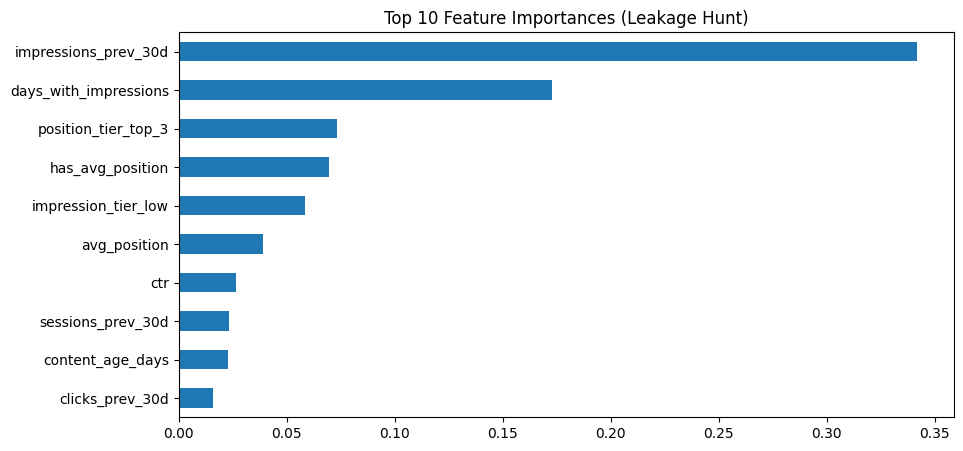

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

accuracy = clf.score(X_test, y_test)
base_rate = y.mean()

print(f"Base Rate (Majority Class): {base_rate:.4f}")
print(f"Baseline RF Accuracy: {accuracy:.4f}")
print("-" * 30)

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Leakage Hunt)')
plt.gca().invert_yaxis()
plt.show()

## 4. What I excluded and why

*The list of fields you refused to use — with one line of why each.*

| Excluded Feature | Reason for Exclusion |
| :--- | :--- |
| `content_id`, `client_id` | Pseudonyms; removed to prevent memorization of specific entities or groups (privacy and generalization check). |
| `trend_direction`, `trend_pct` | Label trap; observed as the computational source of the target label. |
| `is_declining_label` | The target itself. |
| All `_90d` columns (e.g., `clicks_90d`) | Window overlap; observed to contain the target's recent 30-day time period, providing future knowledge. |
| All `_last_30d` columns | Window overlap; strictly aligns with the target's time period, causing direct leakage. |

## Self-check

Before you submit, confirm each line honestly:

- [ **X** ] Every section above is filled — markdown thinking AND the code that backs it
- [ **X** ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ **X** ] No client names, URLs, or private queries anywhere
- [ **X** ] My claims use careful words: observed, measured, directional, decision-support
- [ **X** ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.